In [97]:
import pandas as pd

# Amazon Cardinality

In [98]:
results_df =  pd.read_csv('C:\\Users\Ronza\Dev\DP-MSD\\amazon\\results\\results_from_server\Amazon_Greedy_Results.csv')

In [99]:
results_df

,alg,k,lambda_param,eps,rep,value,relevance,diversity,queries,time_sec
0,nonpriv,10,0.1,0.2,0,0.206032,0.196940,0.287856,9957,2.8897
1,DPGreedy,10,0.1,0.2,0,0.206032,0.196940,0.287856,9957,2.8772
2,DPSampleOblGreedy,10,0.1,0.2,0,0.198343,0.192999,0.246443,2310,0.8144
3,DPSampleGreedy,10,0.1,0.2,0,0.206289,0.201547,0.248975,4489,1.4842
4,Random,10,0.1,0.2,0,0.031115,0.001637,0.296421,0,0.0009
...,...,...,...,...,...,...,...,...,...,...
2995,nonpriv,60,0.1,2.0,9,0.478295,0.501795,0.266799,58232,16.4953
2996,DPGreedy,60,0.1,2.0,9,0.478295,0.501795,0.266799,58232,16.4989
2997,DPSampleOblGreedy,60,0.1,2.0,9,0.441223,0.461300,0.260530,2328,2.0355
2998,DPSampleGreedy,60,0.1,2.0,9,0.475310,0.498972,0.262355,8079,3.6019


## Impact of k on score

In [100]:
results_df['alg'] = results_df['alg'].replace(
    {
        'nonpriv': 'Greedy',
        'DPGreedy': 'DP-Greedy',
        'DPSampleOblGreedy': 'DP-OSG',
        'DPSampleGreedy': 'DP-NOSG',
        'Random': 'Random'
    }
)

In [101]:
print(results_df.head())    

         alg   k  lambda_param  eps  rep     value  relevance  diversity  \
0     Greedy  10           0.1  0.2    0  0.206032   0.196940   0.287856   
1  DP-Greedy  10           0.1  0.2    0  0.206032   0.196940   0.287856   
2     DP-OSG  10           0.1  0.2    0  0.198343   0.192999   0.246443   
3    DP-NOSG  10           0.1  0.2    0  0.206289   0.201547   0.248975   
4     Random  10           0.1  0.2    0  0.031115   0.001637   0.296421   

   queries  time_sec  
0     9957    2.8897  
1     9957    2.8772  
2     2310    0.8144  
3     4489    1.4842  
4        0    0.0009  


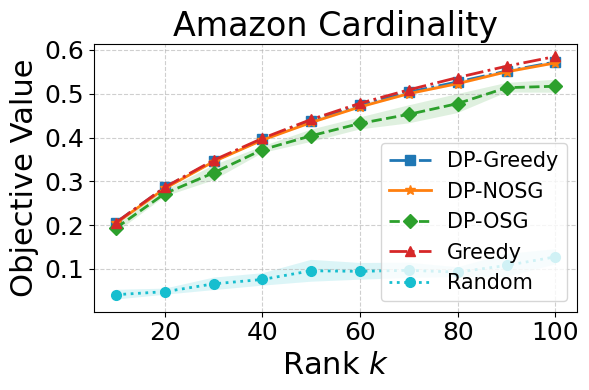

In [102]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.2) & (results_df['lambda_param'] == 0.1)]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['k'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )
    # plt.errorbar(
    #     alg_data['k'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  # Slightly thicker lines
    #     markersize=6,  # Larger markers for better visibility
    #     capsize=6       # Distinct caps for the error bars
    # )

# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Amazon Cardinality', fontsize=24)

plt.xticks(range(20, 110, 20), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=15, frameon=True) # Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_cardinality_k_on_val.pdf')
plt.show()

In [103]:
print(stats)

          alg    k      mean       std
0   DP-Greedy   10  0.206018  0.000078
1   DP-Greedy   20  0.286211  0.000737
2   DP-Greedy   30  0.346497  0.001476
3   DP-Greedy   40  0.396054  0.001406
4   DP-Greedy   50  0.438501  0.001097
5   DP-Greedy   60  0.473289  0.002300
6   DP-Greedy   70  0.503934  0.001734
7   DP-Greedy   80  0.527086  0.002307
8   DP-Greedy   90  0.551795  0.002505
9   DP-Greedy  100  0.572559  0.003073
10    DP-NOSG   10  0.204699  0.002750
11    DP-NOSG   20  0.283817  0.002248
12    DP-NOSG   30  0.345107  0.001790
13    DP-NOSG   40  0.394380  0.001681
14    DP-NOSG   50  0.434457  0.003475
15    DP-NOSG   60  0.470049  0.002227
16    DP-NOSG   70  0.500348  0.003165
17    DP-NOSG   80  0.523195  0.003538
18    DP-NOSG   90  0.550089  0.003329
19    DP-NOSG  100  0.570451  0.003203
20     DP-OSG   10  0.193392  0.010567
21     DP-OSG   20  0.272295  0.007035
22     DP-OSG   30  0.319572  0.017150
23     DP-OSG   40  0.372359  0.007555
24     DP-OSG   50  0.404

In [104]:
import pandas as pd

# 1. Filter the dataset for k <= 60
stats_subset = stats[stats['k'] <= 60].copy()

# 2. Extract the Greedy baseline values for each 'k' in this subset
greedy_ref = stats_subset[stats_subset['alg'] == 'Greedy'][['k', 'mean']].rename(columns={'mean': 'greedy_mean'})

# 3. Merge reference back into the subset
df_merged = pd.merge(stats_subset, greedy_ref, on='k')

# 4. Calculate the % decrease
df_merged['pct_decrease'] = (df_merged['greedy_mean'] - df_merged['mean']) / df_merged['greedy_mean'] * 100

# 5. Group by algorithm to find the average drop for k <= 60
k_60_summary = df_merged.groupby('alg')['pct_decrease'].mean().reset_index()

k_60_summary.columns = ['Algorithm', 'Avg % Below Greedy (k <= 60)']
print(k_60_summary.sort_values(by='Avg % Below Greedy (k <= 60)'))

   Algorithm  Avg % Below Greedy (k <= 60)
3     Greedy                      0.000000
0  DP-Greedy                      0.488851
1    DP-NOSG                      1.136976
2     DP-OSG                      7.322949
4     Random                     80.587666


## Impact of eps on score

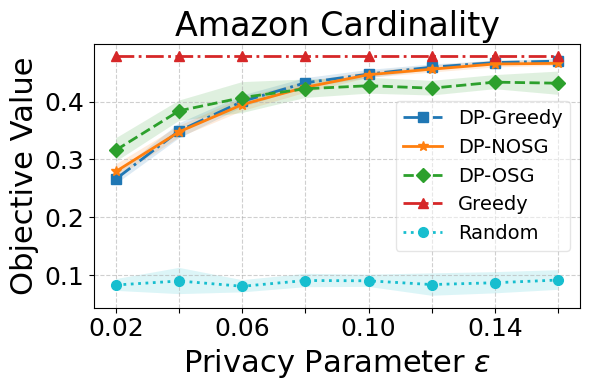

In [118]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filter the data for k=15 and lambda_param=0.1
target_k = 60
# eps_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16]
eps_list = [0.02, 0.04,  0.06, 0.08, 0.1, 0.12, 0.14, 0.16]
# eps_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]

filtered_df = results_df[
    (results_df['k'] == target_k) & 
    (results_df['lambda_param'] == 0.1) & 
    (results_df['eps'].round(2).isin(eps_list)) 
]

# 2. Group by algorithm and 'eps' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'eps'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with your exact requested sizes
plt.figure(figsize=(6, 4)) # Exact size from your reference

# Define specific styles
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    line, = plt.plot(
    alg_data['eps'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['eps'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )    
    # plt.errorbar(
    #     alg_data['eps'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  
    #     markersize=6,   # Exact size from your reference
    #     capsize=6       
    # )

# Formatting with exact fontsizes from your reference
plt.xlabel('Privacy Parameter $\\varepsilon$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Amazon Cardinality', fontsize=24)

# Show only even ticks to avoid crowding: 0.02, 0.04, 0.06, 0.08, 0.10
# 1. Set ticks for ALL points in eps_list to ensure grid lines appear everywhere
plt.xticks(eps_list)

# 2. Get the current axes to customize labels
ax = plt.gca()

# 3. Create a list of labels: show the value if index is even, otherwise an empty string
# This keeps the grid line (because the tick exists) but hides the text
tick_labels = [f"{val:.2f}" if i % 2 == 0 else "" for i, val in enumerate(eps_list)]
ax.set_xticklabels(tick_labels, fontsize=18)

# 4. Enable the grid (it will now draw at every tick location)
plt.grid(True, linestyle='--', alpha=0.6)
plt.yticks(fontsize=18)

plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Exact size from your reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.savefig('amazon_cardinality_eps_on_val.pdf')
plt.show()

In [120]:
import pandas as pd

# 1. Filter the dataset for epsilon = 0.1
stats_01 = stats[stats['eps'] == 0.14].copy()

# 2. Identify the Greedy value for this specific epsilon
greedy_val = stats_01[stats_01['alg'] == 'Greedy']['mean'].values[0]

# 3. Calculate percentage decrease for each algorithm
# Formula: (Greedy - Mean) / Greedy * 100
stats_01['pct_below_greedy'] = (greedy_val - stats_01['mean']) / greedy_val * 100

# 4. Display sorted results
comparison = stats_01[['alg', 'mean', 'pct_below_greedy']].sort_values(by='pct_below_greedy')
print(f"Comparison at epsilon = 0.1 (Greedy Reference: {greedy_val:.4f})")
print(comparison.to_string(index=False))

Comparison at epsilon = 0.1 (Greedy Reference: 0.4783)
      alg     mean  pct_below_greedy
   Greedy 0.478295          0.000000
DP-Greedy 0.467457          2.265944
  DP-NOSG 0.465015          2.776458
   DP-OSG 0.433609          9.342749
   Random 0.086774         81.857536


## Impact of k on num queries

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[
    (results_df['eps'] == 0.2) 
    & (results_df['lambda_param'] == 0.1) 
    & results_df['k'].isin(list(range(10, 110, 10)))
    & ~results_df['alg'].isin(['Random'])
    
]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['queries'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['k'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )
    # plt.errorbar(
    #     alg_data['k'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=3,  # Slightly thicker lines
    #     markersize=6,  # Larger markers for better visibility
    #     capsize=6       # Distinct caps for the error bars
    # )

# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Oracle Queries', fontsize=22)
plt.title('Amazon Cardinality', fontsize=24)

plt.xticks(range(20, 110, 20), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_cardinality_k_on_queries.pdf')
plt.show()

## Impact of k on execution time

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.2) & ~results_df['alg'].isin(['Random']) & (results_df['lambda_param'] == 0.1) & results_df['k'].isin(list(range(10, 110, 10)))]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['time_sec'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['k'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )
    # plt.errorbar(
    #     alg_data['k'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  # Slightly thicker lines
    #     markersize=6,  # Larger markers for better visibility
    #     capsize=6       # Distinct caps for the error bars
    # )

# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Execution Time (s)', fontsize=22)
plt.title('Amazon Cardinality', fontsize=24)

plt.xticks(range(20, 110, 20), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_cardinality_k_on_time.pdf')
plt.show()

In [ ]:
import pandas as pd

# 1. Filter for k=80
stats_80 = stats[stats['k'] == 100].copy()

# 2. Get the Greedy reference time
greedy_time = stats_80[stats_80['alg'] == 'Greedy']['mean'].values[0]

# 3. Calculate Speedup Factor (Time_Greedy / Time_Alg)
# This gives you the "x times faster" value
stats_80['speedup_factor'] = greedy_time / stats_80['mean']

# 4. Show results
print(f"Speedup Analysis at k=80 (Greedy Baseline: {greedy_time:.2f}s)")
print("-" * 50)
comparison = stats_80[['alg', 'mean', 'speedup_factor']].sort_values(by='speedup_factor', ascending=False)

for index, row in comparison.iterrows():
    if row['alg'] == 'Greedy':
        print(f"{row['alg']:12} | {row['mean']:6.2f}s | Baseline")
    else:
        print(f"{row['alg']:12} | {row['mean']:6.2f}s | {row['speedup_factor']:.2f}x faster")

# Matroid Constraints

## Impact of lambda on score

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filter the data for k=15 and lambda_param=0.1
target_k = 60
lambda_list = [0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

filtered_df = results_df[
    (results_df['k'] == target_k) 
    # (results_df['lambda_param'].round(2).isin(eps_list)) 
]

# 2. Group by algorithm and 'eps' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'lambda_param'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with your exact requested sizes
plt.figure(figsize=(6, 4)) # Exact size from your reference

# Define specific styles
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    line, = plt.plot(
    alg_data['lambda_param'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['lambda_param'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )    
    # plt.errorbar(
    #     alg_data['eps'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  
    #     markersize=6,   # Exact size from your reference
    #     capsize=6       
    # )

# Formatting with exact fontsizes from your reference
plt.xlabel('$\\lambda$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Amazon Cardinality', fontsize=24)

# Show only even ticks to avoid crowding: 0.02, 0.04, 0.06, 0.08, 0.10
plt.xticks(lambda_list[1::2], fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Exact size from your reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.savefig('amazon_cardinality_lambda_on_val.pdf')
plt.show()

In [ ]:
import pandas as pd

# Assuming your DataFrame is named 'stats'
# 1. Extract the Greedy baseline values for each lambda
greedy_baseline = stats[stats['alg'] == 'Greedy'][['lambda_param', 'mean']].rename(columns={'mean': 'greedy_mean'})

# 2. Merge the greedy baseline back into the stats table
df_merged = pd.merge(stats, greedy_baseline, on='lambda_param')

# 3. Calculate the percentage decrease for each row
# Formula: (Greedy_Value - Current_Value) / Greedy_Value * 100
df_merged['pct_decrease'] = (df_merged['greedy_mean'] - df_merged['mean']) / df_merged['greedy_mean'] * 100

# 4. Compute the average decrease across all lambda choices for each algorithm
final_comparison = df_merged.groupby('alg')['pct_decrease'].mean().reset_index()

# Formatting for a clean display
final_comparison.columns = ['Algorithm', 'Avg % Decrease vs Greedy']
print(final_comparison.sort_values(by='Avg % Decrease vs Greedy'))